In [110]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
from sklearn.model_selection import train_test_split
import os

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [111]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('aptos2019-blindness-detection')
image_dir = os.path.join(path, "train_images")
print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/aptos2019-blindness-detection


In [112]:
# ==========================================
# 2. Load labels
# ==========================================

csv_path = os.path.join(path, "train.csv")

df = pd.read_csv(csv_path)

print("\nOriginal dataset:")
print(df.head())

print("\nClass distribution:")
print(df["diagnosis"].value_counts().sort_index())



Original dataset:
        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0

Class distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


In [113]:
# ==========================================
# 3. Stratified sampling
# ==========================================

# Sample 30% of the complete dataset
sample_fraction = 0.30

sample_df, _ = train_test_split(
    df,
    test_size=1 - sample_fraction,
    stratify=df["diagnosis"],
    random_state=42
)

sample_df = sample_df.reset_index(drop=True)


In [114]:

# ==========================================
# 4. Check sampled distribution
# ==========================================

print("\nSample size:", len(sample_df))

print("\nSampled class distribution:")
print(sample_df["diagnosis"].value_counts().sort_index())

print("\nSampled class percentage:")
print(
    sample_df["diagnosis"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)


Sample size: 1098

Sampled class distribution:
diagnosis
0    541
1    111
2    300
3     58
4     88
Name: count, dtype: int64

Sampled class percentage:
diagnosis
0    49.27
1    10.11
2    27.32
3     5.28
4     8.01
Name: proportion, dtype: float64


In [115]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    sample_df,
    test_size=0.2,
    stratify=sample_df["diagnosis"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))

print("\nTrain distribution:")
print(train_df["diagnosis"].value_counts().sort_index())

print("\nValidation distribution:")
print(val_df["diagnosis"].value_counts().sort_index())

Train: 878
Validation: 220

Train distribution:
diagnosis
0    433
1     89
2    240
3     46
4     70
Name: count, dtype: int64

Validation distribution:
diagnosis
0    108
1     22
2     60
3     12
4     18
Name: count, dtype: int64


In [116]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [117]:
from torch.utils.data import Dataset
from PIL import Image
import os


class APTOSDataset(Dataset):

    def __init__(self, dataframe, image_dir, transform=None):

        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_id = row["id_code"]
        label = int(row["diagnosis"])

        image_path = os.path.join(
            self.image_dir,
            image_id + ".png"
        )

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [118]:
train_dataset = APTOSDataset(
    train_df,
    image_dir,
    train_transform
)

val_dataset = APTOSDataset(
    val_df,
    image_dir,
    val_transform
)

In [119]:
print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))

Train dataset: 878
Validation dataset: 220


In [120]:
image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([3, 224, 224])
Label: 0


In [121]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [122]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Images shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])
Labels: tensor([0, 0, 0, 3, 0, 0, 0, 0, 0, 4, 2, 2, 0, 4, 0, 1])


In [123]:
val_images, val_labels = next(iter(val_loader))

print("Validation images:", val_images.shape)
print("Validation labels:", val_labels.shape)

Validation images: torch.Size([16, 3, 224, 224])
Validation labels: torch.Size([16])


In [124]:
import torch

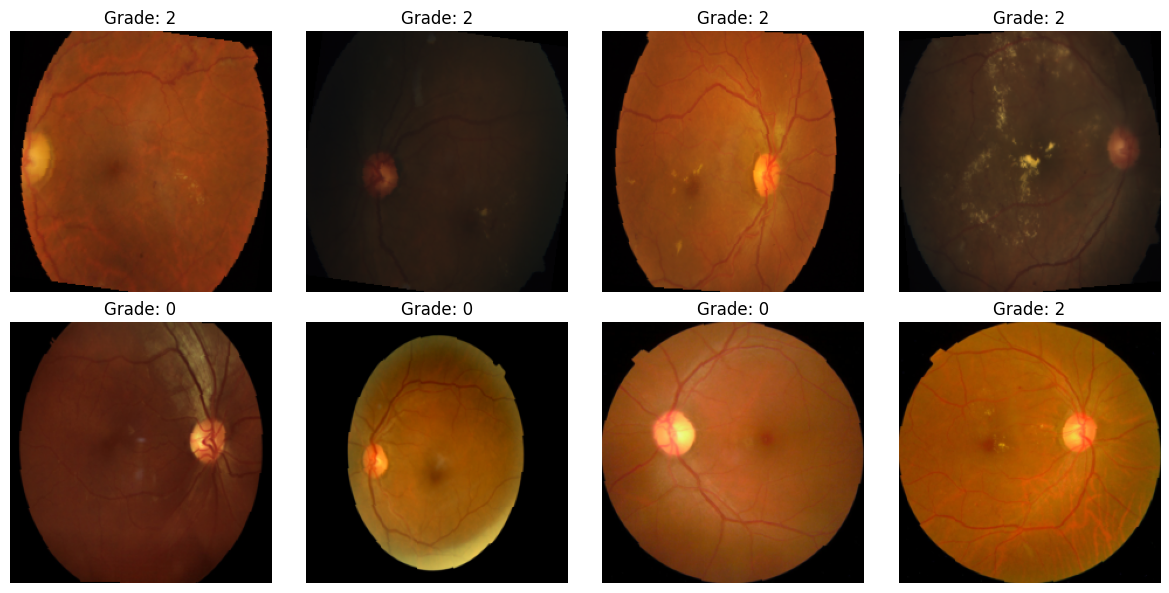

In [125]:
import matplotlib.pyplot as plt

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):

    # Undo normalization for visualization
    img = images[i].permute(1, 2, 0)

    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])

    img = img * std + mean
    img = img.clamp(0, 1)

    ax.imshow(img)
    ax.set_title(f"Grade: {labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [126]:
import torch
import torch.nn as nn
import timm

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using:", device)

model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=5
)

model = model.to(device)

Using: cpu


In [127]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)

print("Input:", images.shape)
print("Output:", outputs.shape)

Input: torch.Size([16, 3, 224, 224])
Output: torch.Size([16, 5])


In [128]:
probabilities = torch.softmax(outputs, dim=1)

print(probabilities[0])

tensor([0.3336, 0.2838, 0.1423, 0.1282, 0.1120])


In [129]:
prediction = probabilities.argmax(dim=1)

print("Predictions:", prediction)
print("Actual:", labels)

Predictions: tensor([0, 0, 1, 2, 0, 3, 0, 0, 0, 0, 2, 2, 1, 1, 0, 1])
Actual: tensor([2, 0, 0, 0, 0, 2, 0, 2, 4, 0, 2, 0, 0, 2, 1, 2])


In [130]:
import torch.nn.functional as F
import torch.nn as nn

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(
            logits,
            targets,
            reduction="none"
        )

        pt = torch.exp(-ce_loss)

        focal_loss = (
            self.alpha
            * (1 - pt) ** self.gamma
            * ce_loss
        )

        return focal_loss.mean()

In [131]:
criterion = FocalLoss(
    alpha=0.25,
    gamma=2.0
)

In [132]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4
)

In [133]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Clear old gradients
        optimizer.zero_grad()

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [134]:
train_loss, train_acc = train_one_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    device
)

print("Train Loss:", train_loss)
print("Train Accuracy:", train_acc)

Train Loss: 0.12893299811046596
Train Accuracy: 0.6890660592255126


In [135]:
with torch.no_grad():
    outputs = model(images)

In [136]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [137]:
model.eval()

x, y = train_dataset[0]

x = x.unsqueeze(0).to(device)

with torch.no_grad():
    features = model.forward_features(x)

print("Input shape:", x.shape)
print("Feature shape:", features.shape)
print("Label:", y)

Input shape: torch.Size([1, 3, 224, 224])
Feature shape: torch.Size([1, 7, 7, 768])
Label: 0


In [138]:
def generate_gradcam(model, image, target_class=None):
    model.eval()

    # Add batch dimension
    image = image.unsqueeze(0).to(device)

    # Forward pass
    features = model.forward_features(image)

    # We need gradients w.r.t. feature map
    features.retain_grad()

    # Same classification head used by the model
    logits = model.forward_head(features)

    # If target class is not given, use predicted class
    if target_class is None:
        target_class = logits.argmax(dim=1).item()

    # Take score of target class
    score = logits[0, target_class]

    # Clear old gradients
    model.zero_grad()

    # Backpropagate
    score.backward()

    # [1, 7, 7, 768]
    gradients = features.grad

    # Grad-CAM weights
    # Average gradients over spatial dimensions
    weights = gradients.mean(dim=(1, 2), keepdim=True)

    # Weighted combination of feature maps
    cam = (weights * features).sum(dim=-1)

    # ReLU
    cam = F.relu(cam)

    # Remove batch dimension
    cam = cam[0]

    # Normalize between 0 and 1
    cam = cam - cam.min()

    if cam.max() > 0:
        cam = cam / cam.max()

    # Convert 7x7 -> 224x224
    cam = F.interpolate(
        cam.unsqueeze(0).unsqueeze(0),
        size=(224, 224),
        mode="bilinear",
        align_corners=False
    )

    cam = cam[0, 0].detach().cpu().numpy()

    return cam, target_class, logits.detach().cpu()

In [139]:
x, y = train_dataset[0]

cam, predicted_class, logits = generate_gradcam(
    model,
    x
)

print("True class:", y)
print("Predicted class:", predicted_class)
print("Logits:", logits)
print("CAM shape:", cam.shape)

True class: 0
Predicted class: 0
Logits: tensor([[ 3.9536,  1.0258, -0.5293, -1.9893, -1.9126]])
CAM shape: (224, 224)


In [140]:
def denormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    img = img.cpu() * std + mean
    return img.clamp(0, 1)

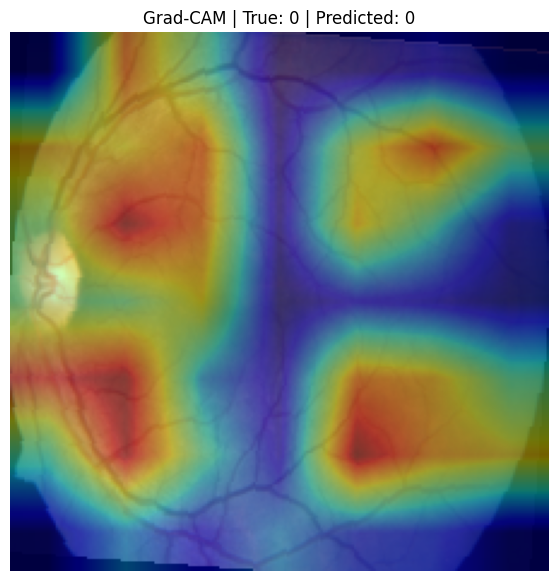

In [141]:
img = denormalize(x)

plt.figure(figsize=(7, 7))

plt.imshow(img.permute(1, 2, 0).numpy())
plt.imshow(cam, cmap="jet", alpha=0.45)

plt.title(
    f"Grad-CAM | True: {y} | Predicted: {predicted_class}"
)

plt.axis("off")
plt.show()

In [142]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# cam is already your 224x224 Grad-CAM
threshold = np.quantile(cam, 0.5)

lesion_mask = (cam >= threshold).astype(np.uint8)

print("Threshold:", threshold)
print("Mask shape:", lesion_mask.shape)

Threshold: 0.40996587
Mask shape: (224, 224)


In [143]:
kernel = np.ones((3, 3), np.uint8)

lesion_mask = cv2.morphologyEx(
    lesion_mask,
    cv2.MORPH_OPEN,
    kernel
)

lesion_mask = cv2.morphologyEx(
    lesion_mask,
    cv2.MORPH_CLOSE,
    kernel
)

In [144]:
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    lesion_mask,
    connectivity=8
)

boxes = []

for i in range(1, num_labels):

    x, y, w, h, area = stats[i]

    # Ignore extremely tiny regions
    if area < 20:
        continue

    boxes.append({
        "x": int(x),
        "y": int(y),
        "width": int(w),
        "height": int(h),
        "area": int(area)
    })

print("Lesion regions:", len(boxes))
print(boxes)

Lesion regions: 3
[{'x': 0, 'y': 0, 'width': 96, 'height': 201, 'area': 15570}, {'x': 131, 'y': 30, 'width': 93, 'height': 65, 'area': 3592}, {'x': 124, 'y': 126, 'width': 100, 'height': 72, 'area': 5922}]


In [145]:
# Get a fresh sample
image, label = train_dataset[0]

print(type(image))
print("Image shape:", image.shape)
print("Label:", label)

<class 'torch.Tensor'>
Image shape: torch.Size([3, 224, 224])
Label: 0


In [146]:
# Generate Grad-CAM again
cam, predicted_class, logits = generate_gradcam(
    model,
    image
)

print("True class:", label)
print("Predicted class:", predicted_class)

True class: 0
Predicted class: 0


In [147]:
img = denormalize(image)

img_np = (
    img.permute(1, 2, 0)
       .numpy()
       .copy()
)

print(img_np.shape)

(224, 224, 3)


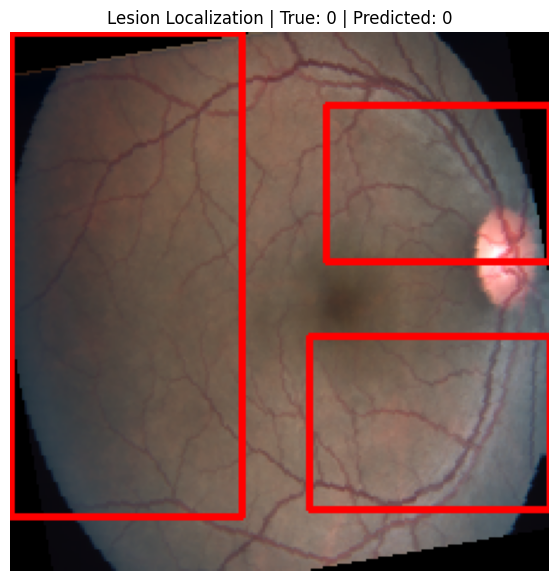

In [148]:
for box in boxes:

    x1 = box["x"]
    y1 = box["y"]
    w = box["width"]
    h = box["height"]

    cv2.rectangle(
        img_np,
        (x1, y1),
        (x1 + w, y1 + h),
        (1, 0, 0),
        2
    )

plt.figure(figsize=(7, 7))
plt.imshow(img_np)

plt.title(
    f"Lesion Localization | True: {label} | Predicted: {predicted_class}"
)

plt.axis("off")
plt.show()

In [149]:
import torch.nn as nn
import torch.nn.functional as F

# Add auxiliary lesion segmentation head
model.seg_head = nn.Conv2d(
    model.num_features,   # 768
    1,
    kernel_size=1
).to(device)

print(model.seg_head)

Conv2d(768, 1, kernel_size=(1, 1), stride=(1, 1))


In [150]:
def image_agent_forward(image):
    image = image.to(device)

    # Swin features
    features = model.forward_features(image)
    
    # Classification
    logits = model.forward_head(features)

    # NHWC -> NCHW
    features_seg = features.permute(0, 3, 1, 2)

    # Lesion segmentation
    lesion_logits = model.seg_head(features_seg)

    # Convert 7x7 lesion map -> 224x224
    lesion_map = F.interpolate(
        lesion_logits,
        size=(224, 224),
        mode="bilinear",
        align_corners=False
    )

    return logits, lesion_map

In [151]:
image, label = train_dataset[0]

image_batch = image.unsqueeze(0).to(device)

logits, lesion_map = image_agent_forward(image_batch)

print("Classification output:", logits.shape)
print("Segmentation output:", lesion_map.shape)

Classification output: torch.Size([1, 5])
Segmentation output: torch.Size([1, 1, 224, 224])


In [152]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    if files:
        # Only show the last 2 folder names, not your full path
        parts = root.split(os.sep)
        safe_path = "/".join(parts[-2:])
        
        print("FOLDER:", safe_path)
        print("FILES:", files[:5])

FOLDER: competitions/aptos2019-blindness-detection
FILES: ['sample_submission.csv', 'train.csv', 'test.csv']
FOLDER: aptos2019-blindness-detection/train_images
FILES: ['ef476be214d4.png', '6dcde47060f9.png', 'ec363f48867b.png', '17f6c7072f61.png', 'b49b2fac2514.png']
FOLDER: aptos2019-blindness-detection/test_images
FILES: ['755615db51d3.png', 'd8f6c660bf2d.png', '619ce2c77917.png', '94a6e4f3c625.png', 'ee506d853270.png']
FOLDER: C. Localization/C. Localization
FILES: ['LICENSE.txt', 'CC-BY-4.0.txt']
FOLDER: 2. Groundtruths/2. Fovea Center Location
FILES: ['IDRiD_Fovea_Center_Testing Set_Markups.csv', 'IDRiD_Fovea_Center_Training Set_Markups.csv']
FOLDER: 2. Groundtruths/1. Optic Disc Center Location
FILES: ['a. IDRiD_OD_Center_Training Set_Markups.csv', 'b. IDRiD_OD_Center_Testing Set_Markups.csv']
FOLDER: 1. Original Images/a. Training Set
FILES: ['IDRiD_179.jpg', 'IDRiD_193.jpg', 'IDRiD_316.jpg', 'IDRiD_407.jpg', 'IDRiD_335.jpg']
FOLDER: 1. Original Images/b. Testing Set
FILES: ['ID

In [153]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    if "IDRiD_02_MA.tif" in files:
        print("MA PATH:", root)

    if "IDRiD_29_HE.tif" in files:
        print("HE PATH:", root)

    if "IDRiD_30_EX.tif" in files:
        print("EX PATH:", root)

    if "IDRiD_17_SE.tif" in files:
        print("SE PATH:", root)

EX PATH: /kaggle/input/datasets/divyanshukj4495/idrid-lesion-segmentation/A. Segmentation/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/3. Hard Exudates
HE PATH: /kaggle/input/datasets/divyanshukj4495/idrid-lesion-segmentation/A. Segmentation/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/2. Haemorrhages
MA PATH: /kaggle/input/datasets/divyanshukj4495/idrid-lesion-segmentation/A. Segmentation/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/1. Microaneurysms
SE PATH: /kaggle/input/datasets/divyanshukj4495/idrid-lesion-segmentation/A. Segmentation/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/4. Soft Exudates


In [154]:
MA_PATH = "/kaggle/input/datasets/divyanshukj4495/idrid-lesion-segmentation/A. Segmentation/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/1. Microaneurysms"

HE_PATH = "/kaggle/input/datasets/divyanshukj4495/idrid-lesion-segmentation/A. Segmentation/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/2. Haemorrhages"

EX_PATH = "/kaggle/input/datasets/divyanshukj4495/idrid-lesion-segmentation/A. Segmentation/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/3. Hard Exudates"

SE_PATH = "/kaggle/input/datasets/divyanshukj4495/idrid-lesion-segmentation/A. Segmentation/A. Segmentation/2. All Segmentation Groundtruths/a. Training Set/4. Soft Exudates"

In [155]:
import os

print("MA:", len(os.listdir(MA_PATH)))
print("HE:", len(os.listdir(HE_PATH)))
print("EX:", len(os.listdir(EX_PATH)))
print("SE:", len(os.listdir(SE_PATH)))

print("\nExample:")
print(os.listdir(MA_PATH)[:5])

MA: 54
HE: 53
EX: 54
SE: 26

Example:
['IDRiD_02_MA.tif', 'IDRiD_16_MA.tif', 'IDRiD_46_MA.tif', 'IDRiD_34_MA.tif', 'IDRiD_05_MA.tif']


In [156]:
from PIL import Image
import numpy as np
import os

def load_mask_if_exists(path, filename, shape):
    """
    Load mask if it exists.
    If missing, return an empty mask.
    """
    file_path = os.path.join(path, filename)

    if os.path.exists(file_path):
        mask = np.array(Image.open(file_path))
        return mask > 0

    # Missing annotation = no annotated pixels for this lesion
    return np.zeros(shape, dtype=bool)


def load_combined_mask(image_id):
    # Use MA as reference to get image/mask size
    ma_file = os.path.join(MA_PATH, image_id + "_MA.tif")
    ma = np.array(Image.open(ma_file))

    shape = ma.shape

    he = load_mask_if_exists(
        HE_PATH,
        image_id + "_HE.tif",
        shape
    )

    ex = load_mask_if_exists(
        EX_PATH,
        image_id + "_EX.tif",
        shape
    )

    se = load_mask_if_exists(
        SE_PATH,
        image_id + "_SE.tif",
        shape
    )

    ma = ma > 0

    # Combine all lesion types
    combined = ma | he | ex | se

    return combined.astype(np.uint8)

In [157]:
mask = load_combined_mask("IDRiD_02")

print("Mask shape:", mask.shape)
print("Unique values:", np.unique(mask))
print("Lesion pixels:", mask.sum())

Mask shape: (2848, 4288)
Unique values: [0 1]
Lesion pixels: 162182


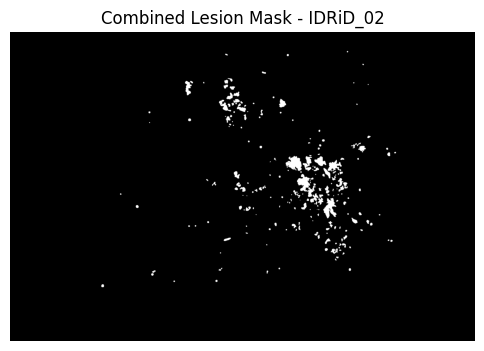

In [158]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(mask, cmap="gray")
plt.title("Combined Lesion Mask - IDRiD_02")
plt.axis("off")
plt.show()

In [159]:
class IDRiDSegmentationDataset(Dataset):

    def __init__(self, image_dir):

        self.image_dir = image_dir

        # All original images
        image_files = [
            f for f in os.listdir(image_dir)
            if f.lower().endswith(".jpg")
        ]

        # Map numeric ID -> actual filename
        self.image_map = {}

        for f in image_files:
            number = f.split("_")[-1].split(".")[0]
            number = int(number)

            self.image_map[number] = f

        # Only IDs for which MA mask exists
        mask_files = [
            f for f in os.listdir(MA_PATH)
            if f.endswith("_MA.tif")
        ]

        self.image_ids = []

        for f in mask_files:

            number = f.split("_")[1]

            # Remove leading zeros
            number = int(number)

            if number in self.image_map:
                self.image_ids.append(number)

        self.image_ids.sort()

        print(
            "Usable segmentation images:",
            len(self.image_ids)
        )

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):

        number = self.image_ids[idx]

        # Actual image filename
        image_name = self.image_map[number]

        image_path = os.path.join(
            self.image_dir,
            image_name
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        # IDRiD_02, IDRiD_002 etc.
        image_id = f"IDRiD_{number:02d}"

        # Combined lesion mask
        mask = load_combined_mask(image_id)

        mask = Image.fromarray(
            mask * 255
        )

        # Resize
        image = image.resize(
            (224, 224)
        )

        mask = mask.resize(
            (224, 224),
            Image.Resampling.NEAREST
        )

        # Tensor
        image = TF.to_tensor(image)
        mask = TF.to_tensor(mask)

        mask = (mask > 0.5).float()

        # Normalize
        mean = torch.tensor(
            [0.485, 0.456, 0.406]
        ).view(3, 1, 1)

        std = torch.tensor(
            [0.229, 0.224, 0.225]
        ).view(3, 1, 1)

        image = (image - mean) / std

        return image, mask

In [160]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    if "IDRiD_179.jpg" in files:
        print(root)

/kaggle/input/datasets/divyanshukj4495/idrid-lesion-segmentation/C. Localization/C. Localization/1. Original Images/a. Training Set
/kaggle/input/datasets/divyanshukj4495/idrid-lesion-segmentation/B. Disease Grading/B. Disease Grading/1. Original Images/a. Training Set


In [161]:
IDRID_IMG_PATH = "/kaggle/input/datasets/divyanshukj4495/idrid-lesion-segmentation/B. Disease Grading/B. Disease Grading/1. Original Images/a. Training Set"

In [162]:
idrid_dataset = IDRiDSegmentationDataset(
    IDRID_IMG_PATH
)

print("Total:", len(idrid_dataset))

Usable segmentation images: 54
Total: 54


In [163]:
image, mask = idrid_dataset[0]

print("Image:", image.shape)
print("Mask:", mask.shape)
print("Mask values:", torch.unique(mask))

Image: torch.Size([3, 224, 224])
Mask: torch.Size([1, 224, 224])
Mask values: tensor([0., 1.])


In [164]:
seg_loader = DataLoader(
    idrid_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

images, masks = next(iter(seg_loader))

print("Images:", images.shape)
print("Masks:", masks.shape)

Images: torch.Size([4, 3, 224, 224])
Masks: torch.Size([4, 1, 224, 224])


In [165]:
model.seg_head = nn.Conv2d(
    model.num_features,
    1,
    kernel_size=1
).to(device)

In [166]:
print(model.seg_head)

Conv2d(768, 1, kernel_size=(1, 1), stride=(1, 1))


In [167]:
import torch.nn as nn

seg_criterion = nn.BCEWithLogitsLoss()

seg_optimizer = torch.optim.AdamW(
    model.seg_head.parameters(),
    lr=1e-3
)

In [168]:
model.eval()
model.seg_head.train()

num_epochs = 3

for epoch in range(num_epochs):

    total_loss = 0

    for images, masks in seg_loader:

        images = images.to(device)
        masks = masks.to(device)

        # Swin feature extraction
        with torch.no_grad():
            features = model.forward_features(images)

        # NHWC -> NCHW
        features = features.permute(0, 3, 1, 2)

        # Segmentation prediction
        lesion_logits = model.seg_head(features)

        # Resize to mask size
        lesion_logits = F.interpolate(
            lesion_logits,
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        )

        loss = seg_criterion(
            lesion_logits,
            masks
        )

        seg_optimizer.zero_grad()
        loss.backward()
        seg_optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(seg_loader)

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"| Segmentation Loss: {avg_loss:.4f}"
    )

Epoch 1/3 | Segmentation Loss: 0.4407
Epoch 2/3 | Segmentation Loss: 0.1537
Epoch 3/3 | Segmentation Loss: 0.1246


In [169]:
model.eval()

image, true_mask = idrid_dataset[0]

with torch.no_grad():

    image_batch = image.unsqueeze(0).to(device)

    features = model.forward_features(image_batch)

    # NHWC -> NCHW
    features = features.permute(0, 3, 1, 2)

    lesion_logits = model.seg_head(features)

    lesion_logits = F.interpolate(
        lesion_logits,
        size=(224, 224),
        mode="bilinear",
        align_corners=False
    )

    pred_mask = torch.sigmoid(
        lesion_logits
    )[0, 0].cpu().numpy()

print("Prediction shape:", pred_mask.shape)
print("Min:", pred_mask.min())
print("Max:", pred_mask.max())

Prediction shape: (224, 224)
Min: 0.0028546469
Max: 0.16105859


In [170]:
pred_binary = (pred_mask >= 0.5).astype(np.uint8)

print("Predicted lesion pixels:", pred_binary.sum())

Predicted lesion pixels: 0


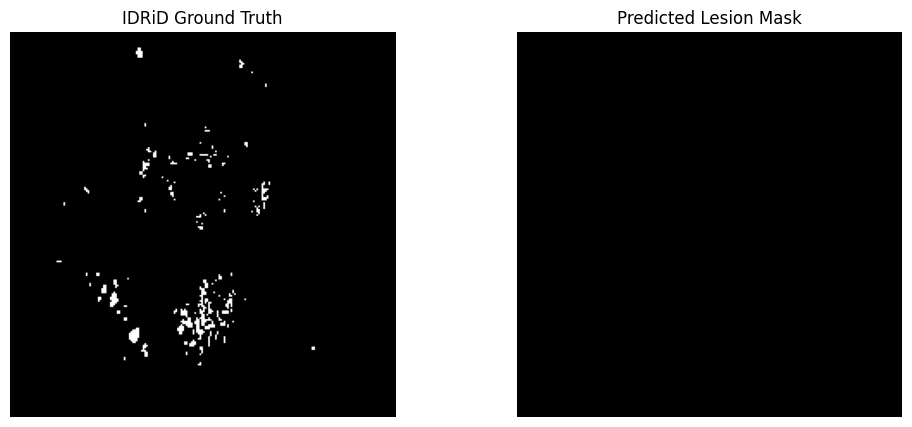

In [171]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(true_mask.squeeze(), cmap="gray")
plt.title("IDRiD Ground Truth")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pred_binary, cmap="gray")
plt.title("Predicted Lesion Mask")
plt.axis("off")

plt.show()

In [172]:
import torchvision.transforms.functional as TF

def get_tta_images(image):
    """
    Returns:
    1. Original
    2. Horizontal flip
    3. Small rotation
    """

    original = image

    flipped = TF.hflip(image)

    rotated = TF.rotate(
        image,
        angle=10
    )

    return [
        original,
        flipped,
        rotated
    ]

In [173]:
def get_grade_prediction(image):

    model.eval()

    with torch.no_grad():

        image = image.unsqueeze(0).to(device)

        features = model.forward_features(image)

        logits = model.forward_head(features)

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        grade = torch.argmax(
            probabilities,
            dim=1
        ).item()

        confidence = probabilities[
            0, grade
        ].item()

    return grade, confidence

In [174]:
image, true_mask = idrid_dataset[0]

tta_images = get_tta_images(image)

tta_results = []

for tta_image in tta_images:

    grade, confidence = get_grade_prediction(
        tta_image
    )

    tta_results.append({
        "grade": grade,
        "confidence": confidence
    })

print(tta_results)

[{'grade': 2, 'confidence': 0.393055260181427}, {'grade': 2, 'confidence': 0.417099267244339}, {'grade': 2, 'confidence': 0.3927344083786011}]


In [175]:
grades = [
    result["grade"]
    for result in tta_results
]

min_grade = min(grades)
max_grade = max(grades)

grade_range = max_grade - min_grade

review_required = grade_range > 1

print("TTA grades:", grades)
print("Grade range:", grade_range)
print("Clinician review:", review_required)

TTA grades: [2, 2, 2]
Grade range: 0
Clinician review: False


In [176]:
def get_image_embedding(image):
    model.eval()

    with torch.no_grad():
        image = image.unsqueeze(0).to(device)
        features = model.forward_features(image)

        # [B, 7, 7, 768] -> [B, 768]
        embedding = features.mean(dim=(1, 2))

    return embedding.squeeze(0).cpu()

In [178]:
cam = generate_gradcam(model, image)

In [183]:
if isinstance(cam, (list, tuple)):
    cam = cam[0]

if torch.is_tensor(cam):
    cam = cam.detach().cpu().numpy()

cam = np.squeeze(cam)

In [189]:
def image_agent(image):
    # 1. Classification
    grade, confidence = get_grade_prediction(image)

    # 2. Image embedding
    image_embedding = get_image_embedding(image)

    # 3. Grad-CAM
    cam_result = generate_gradcam(model, image)
    cam = cam_result[0]

    # 4. Lesion boxes
    threshold = np.quantile(cam, 0.5)
    lesion_mask = (cam >= threshold).astype(np.uint8)

    kernel = np.ones((3, 3), np.uint8)

    lesion_mask = cv2.morphologyEx(
        lesion_mask, cv2.MORPH_OPEN, kernel
    )

    lesion_mask = cv2.morphologyEx(
        lesion_mask, cv2.MORPH_CLOSE, kernel
    )

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        lesion_mask, connectivity=8
    )

    boxes = []

    for i in range(1, num_labels):
        x, y, w, h, area = stats[i]

        if area < 20:
            continue

        boxes.append({
            "x": int(x),
            "y": int(y),
            "width": int(w),
            "height": int(h),
            "area": int(area)
        })

    # 5. Segmentation prediction
    model.eval()

    with torch.no_grad():
        image_batch = image.unsqueeze(0).to(device)

        features = model.forward_features(image_batch)
        features = features.permute(0, 3, 1, 2)

        lesion_logits = model.seg_head(features)

        lesion_logits = F.interpolate(
            lesion_logits,
            size=(224, 224),
            mode="bilinear",
            align_corners=False
        )

        segmentation_mask = torch.sigmoid(
            lesion_logits
        )[0, 0].cpu().numpy()

    # 6. TTA
    tta_images = get_tta_images(image)

    tta_grades = []
    tta_confidences = []

    for tta_image in tta_images:
        g, c = get_grade_prediction(tta_image)
        tta_grades.append(g)
        tta_confidences.append(c)

    grade_range = max(tta_grades) - min(tta_grades)

    # Paper: spread > 1 => clinician review
    review_required = grade_range > 1

    return {
        "grade": grade,
        "confidence": confidence,
        "image_embedding": image_embedding,
        "gradcam": cam,
        "lesion_boxes": boxes,
        "segmentation_mask": segmentation_mask,
        "tta_grades": tta_grades,
        "tta_confidences": tta_confidences,
        "grade_range": grade_range,
        "review_required": review_required
    }

In [186]:
cam = generate_gradcam(model, image)

print(type(cam))
print(len(cam) if isinstance(cam, (list, tuple)) else "not list")

<class 'tuple'>
3


In [187]:
cam_result = generate_gradcam(model, image)

for i, item in enumerate(cam_result):
    print("ITEM", i)
    print("Type:", type(item))
    
    if hasattr(item, "shape"):
        print("Shape:", item.shape)
    elif isinstance(item, np.ndarray):
        print("Shape:", item.shape)
    else:
        print("Value:", item)
        
    print()

ITEM 0
Type: <class 'numpy.ndarray'>
Shape: (224, 224)

ITEM 1
Type: <class 'int'>
Value: 2

ITEM 2
Type: <class 'torch.Tensor'>
Shape: torch.Size([1, 5])



In [190]:
image, _ = idrid_dataset[0]

output = image_agent(image)

print("Grade:", output["grade"])
print("Confidence:", output["confidence"])
print("Embedding:", output["image_embedding"].shape)
print("TTA grades:", output["tta_grades"])
print("Review required:", output["review_required"])
print("Lesion boxes:", len(output["lesion_boxes"]))
print("Segmentation:", output["segmentation_mask"].shape)
print("GradCAM:", output["gradcam"].shape)

Grade: 2
Confidence: 0.393055260181427
Embedding: torch.Size([768])
TTA grades: [2, 2, 2]
Review required: False
Lesion boxes: 1
Segmentation: (224, 224)
GradCAM: (224, 224)
